<a href="https://colab.research.google.com/github/supsi-dacd-isaac/TeachDecisionMakingUncertainty/blob/main/CCP_Gaussian_Au%3C%3Db.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal

# =========================
# Problem parameters
# =========================
a1_min, a1_max = -5, 5
a2_min, a2_max = -5, 5
b_selected = (7.0, 4.0)

mu = np.array([0.0, 1.0])
Sigma = np.array([ [1.0, 0.5],  [0.5, 4.0] ])

# =========================
# Helper functions
def objective_function(a1, a2):
    return a1 + 2 * a2

def make_A(a1, a2):
    return np.array([[1 - a1, a2],  [a1, 1 - a2]], dtype=float)

def transformed_distribution(a1, a2):
    """apply transformation"""
    A = make_A(a1, a2)
    mu_transformed = A @ mu
    Sigma_transformed = A @ Sigma @ A.T
    return A, mu_transformed, Sigma_transformed

def compute_probability_marginal_and_jointly(a1, a2, b=(0.0, 0.0)):
    """compute marginal and joint probabilities"""
    A, mu_transformed, Sigma_transformed = transformed_distribution(a1, a2)

    std_transformed = np.sqrt(np.maximum(np.diag(Sigma_transformed), 1e-12))

    prob_g1 = norm.cdf(b[0], loc=mu_transformed[0], scale=std_transformed[0])
    prob_g2 = norm.cdf(b[1], loc=mu_transformed[1], scale=std_transformed[1])

    prob_joint = multivariate_normal(
                                    mean=mu_transformed,
                                    cov=Sigma_transformed,
                                    allow_singular=True
                                     ).cdf(b)

    return prob_joint, prob_g1, prob_g2


In [72]:
# =========================
# Example 1: transformation
# =========================
a1, a2 = 2, 2

print('--- Example: transformation ---')
print('objective function =', objective_function(a1, a2))
A, mu_transformed, Sigma_transformed = transformed_distribution(a1, a2)

print('A =')
print(A)
print()

print('mean transformed =', mu_transformed)
print()

print('covariance transformed =')
print(Sigma_transformed)
print()

std_transformed = np.sqrt(np.diag(Sigma_transformed))
print('standard deviation transformed =', std_transformed)
print()


--- Example: transformation ---
objective function = 6
A =
[[-1.  2.]
 [ 2. -1.]]

mean transformed = [ 2. -1.]

covariance transformed =
[[15.  -7.5]
 [-7.5  6. ]]

standard deviation transformed = [3.87298335 2.44948974]



In [73]:
# =========================
# Example 2: one feasibility check
# =========================
a1, a2 = 1, 4
alpha = 0.05

print('--- Example: single decision feasibility ---')
print(f'objective function ={objective_function(a1, a2):.2f}')
prob_joint, prob_g1, prob_g2 = compute_probability_marginal_and_jointly(a1, a2, b=b_selected)

print(f'P[g1 <= b1] ={prob_g1:.4f}')
print(f'P[g2 <= b2] ={prob_g2:.4f}')
print(f'P[g1 <= b1 and g2 <= b2] ={prob_joint:.4f}')
print(f'Is P[g1<=b1 and g2<=b2] >= {1-alpha}? (joint feasible)', prob_joint >= 1 - alpha)
print()

# =========================
# Candidate decisions
# =========================
# ANSI helpers (terminal colors)
GREEN = "\033[92m"
RED   = "\033[91m"
RESET = "\033[0m"

def color_bool(x: bool) -> str:
    return f"{GREEN}True{RESET}" if x else f"{RED}False{RESET}"

def evaluate_candidate(a1, a2, b, alpha):
    prob_joint, prob_g1, prob_g2 = compute_probability_marginal_and_jointly(a1, a2, b=b)

    t1 = prob_g1 >= 1 - alpha
    t2 = prob_g2 >= 1 - alpha
    tj = prob_joint >= 1 - alpha
    print(f'Candidate decision (a1, a2) = ({a1}, {a2})')
    print(f'objective function ={objective_function(a1, a2):.2f}')
    print(f'P[g1 <= b1] ={prob_g1:.4f}')
    print(f'P[g2 <= b2] ={prob_g2:.4f}')
    print(f'P[g1 <= b1 and g2 <= b2] ={prob_joint:.4f}')
    print(f'Is P[g1<=b1] >= {1-alpha}?', color_bool(t1))
    print(f'Is P[g2<=b2] >= {1-alpha}?', color_bool(t2))
    print(f'Is P[g1<=b1 and g2<=b2] >= {1-alpha}?', color_bool(tj))
    print()


--- Example: single decision feasibility ---
objective function =9.00
P[g1 <= b1] =0.6462
P[g2 <= b2] =0.8850
P[g1 <= b1 and g2 <= b2] =0.5312
Is P[g1<=b1 and g2<=b2] >= 0.95? (joint feasible) False



In [74]:
alpha = 0.05
one_minus_alpha =  1 -  alpha
alpha = 1 - one_minus_alpha

print('--- First candidate ---')
a1, a2 = -2, -2
evaluate_candidate(a1, a2, b_selected, alpha)

print('--- Second candidate ---')
a1, a2 = 0.2, 0.3
evaluate_candidate(a1, a2, b_selected, alpha)

print('--- Third candidate ---')
a1, a2 = -0.42, 0.75
evaluate_candidate(a1, a2, b_selected, alpha)

--- First candidate ---
Candidate decision (a1, a2) = (-2, -2)
objective function =-6.00
P[g1 <= b1] =0.9805
P[g2 <= b2] =0.5681
P[g1 <= b1 and g2 <= b2] =0.5486
Is P[g1<=b1] >= 0.95? True
Is P[g2<=b2] >= 0.95? False
Is P[g1<=b1 and g2<=b2] >= 0.95? False

--- Second candidate ---
Candidate decision (a1, a2) = (0.2, 0.3)
objective function =0.80
P[g1 <= b1] =1.0000
P[g2 <= b2] =0.9880
P[g1 <= b1 and g2 <= b2] =0.9880
Is P[g1<=b1] >= 0.95? True
Is P[g2<=b2] >= 0.95? True
Is P[g1<=b1 and g2<=b2] >= 0.95? True

--- Third candidate ---
Candidate decision (a1, a2) = (-0.42, 0.75)
objective function =1.08
P[g1 <= b1] =0.9966
P[g2 <= b2] =1.0000
P[g1 <= b1 and g2 <= b2] =0.9966
Is P[g1<=b1] >= 0.95? True
Is P[g2<=b2] >= 0.95? True
Is P[g1<=b1 and g2<=b2] >= 0.95? True



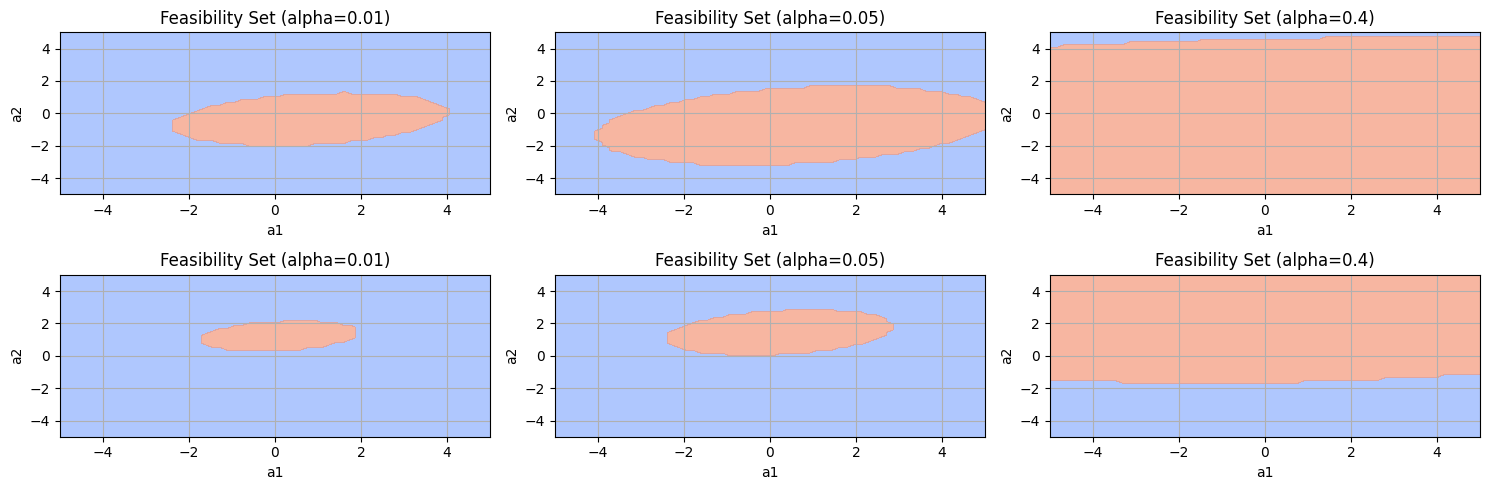

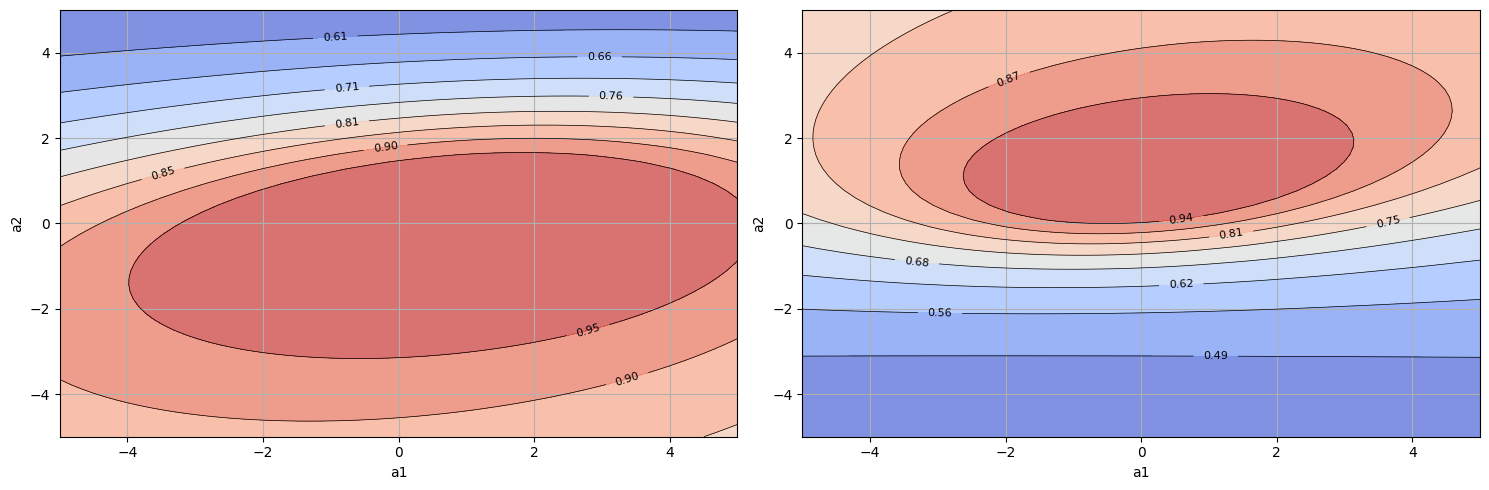

In [80]:
#@title This fuction runs a grid search over the entire design space A, i.e., in the box [-5,+5]
# Define grid for (a1, a2)
n_grid_vals = 60
a1_vals = np.linspace(-5, 5, n_grid_vals)
a2_vals = np.linspace(-5, 5, n_grid_vals)
A1, A2 = np.meshgrid(a1_vals, a2_vals)

# Define the required probability level
alpha_levels = [0.01, 0.05, 0.4]
# Compute feasibility for each alpha level
fig, axes = plt.subplots(2, len(alpha_levels), figsize=(15, 5))
for i, ALPHA in enumerate(alpha_levels):
    one_minus_alpha = 1- ALPHA
    feasibility_g1 = np.zeros_like(A1) # prepare to save results in an matrix (array with all zeros, same size as A1)
    probability_g1 = np.zeros_like(A1)
    feasibility_g2 = np.zeros_like(A1)
    probability_g2 = np.zeros_like(A1)
    objective_function_values = np.zeros_like(A1)

    for x in range(A1.shape[0]):
        for y in range(A1.shape[1]):
            _, prob_g1, prob_g2 = compute_probability_marginal_and_jointly(A1[x, y], A2[x, y],b=b_selected)  # HERE WE ARE ONLY SAVING THE MARGINAL PROBABILITY
            feasibility_g1[x, y] = prob_g1 >= one_minus_alpha  # Compute if it feasibility or not (an indicator function)
            feasibility_g2[x, y] = prob_g2 >= one_minus_alpha

            probability_g1[x, y] = prob_g1  # save probabilities
            probability_g2[x, y] = prob_g2

            objective_function_values[x, y] = objective_function(A1[x, y], A2[x, y]) # save objective function


    # Plot feasibility region
    contour = axes[0,i].contourf(A1, A2, feasibility_g1, levels=1, cmap='coolwarm', alpha=0.7)
    axes[0,i].set_title(f'Feasibility Set (alpha={ALPHA})')
    axes[0,i].set_xlabel('a1')
    axes[0,i].set_ylabel('a2')
    axes[0,i].grid(True)

    contour = axes[1,i].contourf(A1, A2, feasibility_g2, levels=1, cmap='coolwarm', alpha=0.7)
    axes[1,i].set_title(f'Feasibility Set (alpha={ALPHA})')
    axes[1,i].set_xlabel('a1')
    axes[1,i].set_ylabel('a2')
    axes[1,i].grid(True)

plt.tight_layout()
plt.show()


# Plot feasibility region
levels = np.linspace(np.min(probability_g1),np.max(probability_g1),10)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
contour_filled = axes[0].contourf(A1, A2, probability_g1, levels=levels, cmap='coolwarm', alpha=0.7)# Plot contour fill
contour_lines = axes[0].contour(A1, A2, probability_g1, levels=levels, colors='k', linewidths=0.5)# Add contour lines
axes[0].clabel(contour_lines, inline=True, fontsize=8, fmt="%.2f")# Label contour lines
axes[0].set_xlabel('a1')
axes[0].set_ylabel('a2')
axes[0].grid(True)

levels = np.linspace(np.min(probability_g2),np.max(probability_g2),10)
contour_filled = axes[1].contourf(A1, A2, probability_g2, levels=levels, cmap='coolwarm', alpha=0.7)# Plot contour fill
contour_lines = axes[1].contour(A1, A2, probability_g2, levels=levels, colors='k', linewidths=0.5)# Add contour lines
axes[1].clabel(contour_lines, inline=True, fontsize=8, fmt="%.2f")# Label contour lines
axes[1].set_xlabel('a1')
axes[1].set_ylabel('a2')
axes[1].grid(True)

plt.tight_layout()
plt.show()




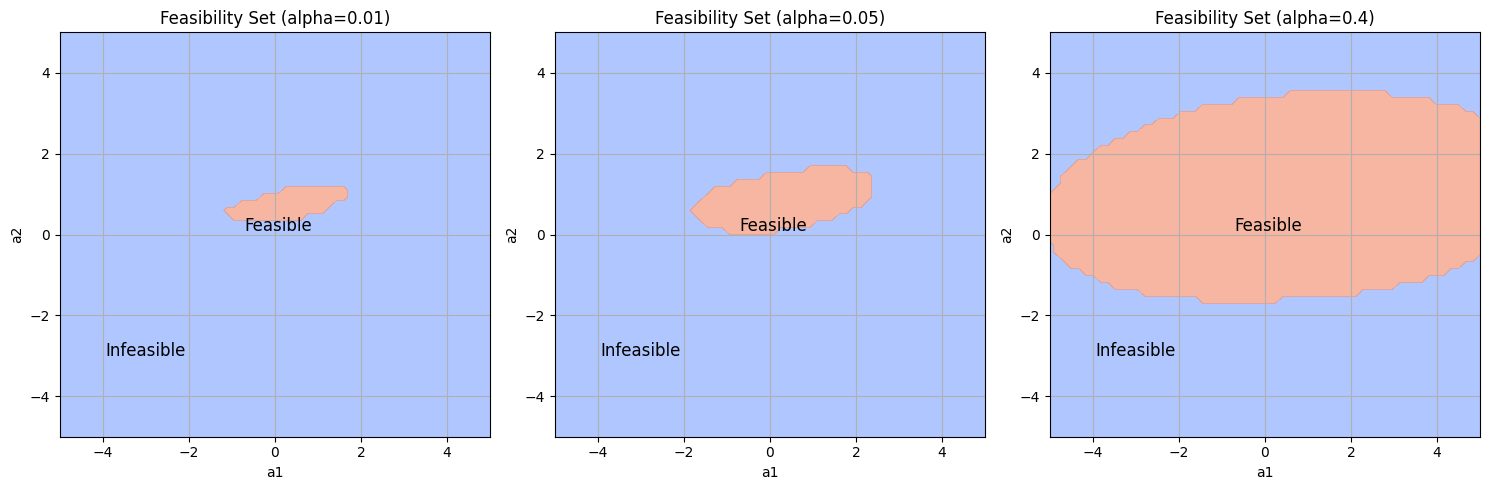

In [84]:
#@title Repeat the analysis, but this this time we focus on the joint Chance Constraint
# Compute feasibility for each alpha level

fig, axes = plt.subplots(1, len(alpha_levels), figsize=(15, 5))
for i, ALPHA in enumerate(alpha_levels):
    one_minus_alpha=1-ALPHA
    feasibility = np.zeros_like(A1)
    probability = np.zeros_like(A1)

    for x in range(A1.shape[0]):
        for y in range(A1.shape[1]):
            prob, _, _ = compute_probability_marginal_and_jointly(A1[x, y], A2[x, y], b=b_selected)  # HERE WE ARE ONLY KEEPING THE JOINT PROBABILITY
            feasibility[x, y] = prob >= one_minus_alpha  # save feasibility
            probability[x, y] = prob  # save probabilities

    # Plot feasibility region
    contour = axes[i].contourf(A1, A2, feasibility, levels=1, cmap='coolwarm', alpha=0.7)
    axes[i].set_title(f'Feasibility Set (alpha={ALPHA})')
    axes[i].set_xlabel('a1')
    axes[i].set_ylabel('a2')
    axes[i].grid(True)

    # Add labels for feasible and infeasible regions
    #if i == len(alpha_levels) - 2:  # Only for the second last subplot

    mid_x, mid_y = A1.shape[0] // 2, A1.shape[1] // 2
    axes[i].text(A1[mid_x, mid_y], A2[mid_x, mid_y], "Feasible", fontsize=12, color='black', ha='center')
    axes[i].text(-3, -3, "Infeasible", fontsize=12, color='black', ha='center')

plt.tight_layout()
plt.show()

--- Grid-search solution for the joint CCP ---
Best decision: a1 = -1.441, a2 = 0.254
Best objective value: -0.932
Joint probability at optimum: 0.9601


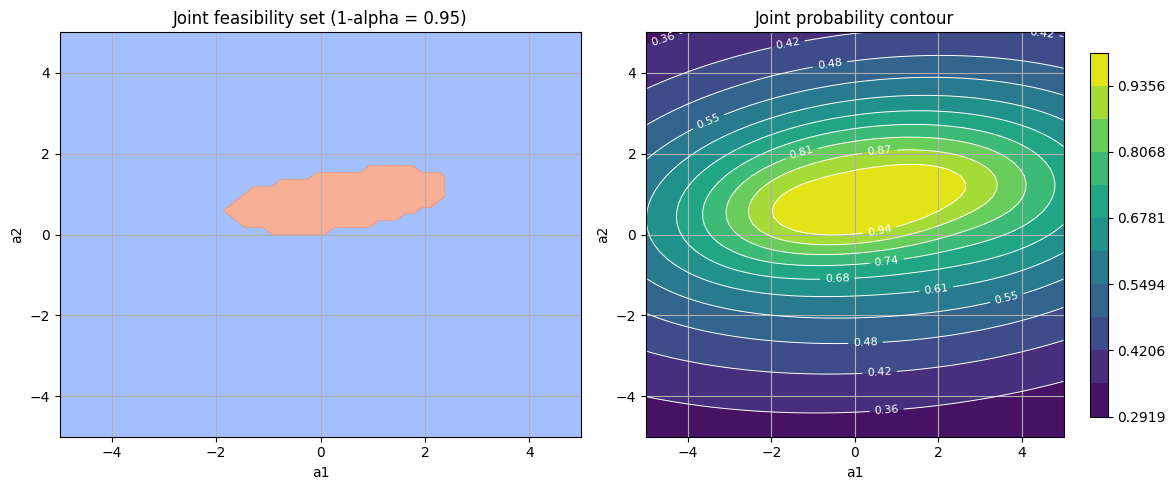

In [77]:
# =========================
# Grid search for joint CCP
# =========================
a1_vals = np.linspace(a1_min, a1_max, n_grid_vals)
a2_vals = np.linspace(a2_min, a2_max, n_grid_vals)
A1, A2 = np.meshgrid(a1_vals, a2_vals)

probability_joint = np.zeros_like(A1)
feasibility_joint = np.zeros_like(A1, dtype=bool)
objective_values = objective_function(A1, A2)

best_obj = np.inf
best_a1, best_a2, best_prob = None, None, None

for i in range(A1.shape[0]):
    for j in range(A1.shape[1]):
        p_joint, _, _ = compute_probability_marginal_and_jointly(
            A1[i, j], A2[i, j], b=b_selected
        )
        probability_joint[i, j] = p_joint
        feasibility_joint[i, j] = p_joint >= one_minus_alpha

        if feasibility_joint[i, j] and objective_values[i, j] < best_obj:
            best_obj = objective_values[i, j]
            best_a1 = A1[i, j]
            best_a2 = A2[i, j]
            best_prob = p_joint

print('--- Grid-search solution for the joint CCP ---')
if best_a1 is None:
    print('No feasible point found on the grid.')
else:
    print(f'Best decision: a1 = {best_a1:.3f}, a2 = {best_a2:.3f}')
    print(f'Best objective value: {best_obj:.3f}')
    print(f'Joint probability at optimum: {best_prob:.4f}')

# =========================
# Plot: joint feasibility
# =========================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].contourf(
    A1, A2, feasibility_joint.astype(float),
    levels=[-0.1, 0.5, 1.1],
    cmap='coolwarm',
    alpha=0.8
)
axes[0].set_title(f'Joint feasibility set (1-alpha = {one_minus_alpha})')
axes[0].set_xlabel('a1')
axes[0].set_ylabel('a2')
axes[0].grid(True)

levels = np.linspace(np.min(probability_joint), np.max(probability_joint), 12)
cf = axes[1].contourf(A1, A2, probability_joint, levels=levels, cmap='viridis')
cl = axes[1].contour(A1, A2, probability_joint, levels=levels, colors='white', linewidths=0.7)
axes[1].clabel(cl, inline=True, fontsize=8, fmt='%.2f')
axes[1].set_title('Joint probability contour')
axes[1].set_xlabel('a1')
axes[1].set_ylabel('a2')
axes[1].grid(True)
fig.colorbar(cf, ax=axes[1], shrink=0.9)

plt.tight_layout()
plt.show()

Optimal a1: -2.1186440677966103
Optimal a2: -0.08474576271186507


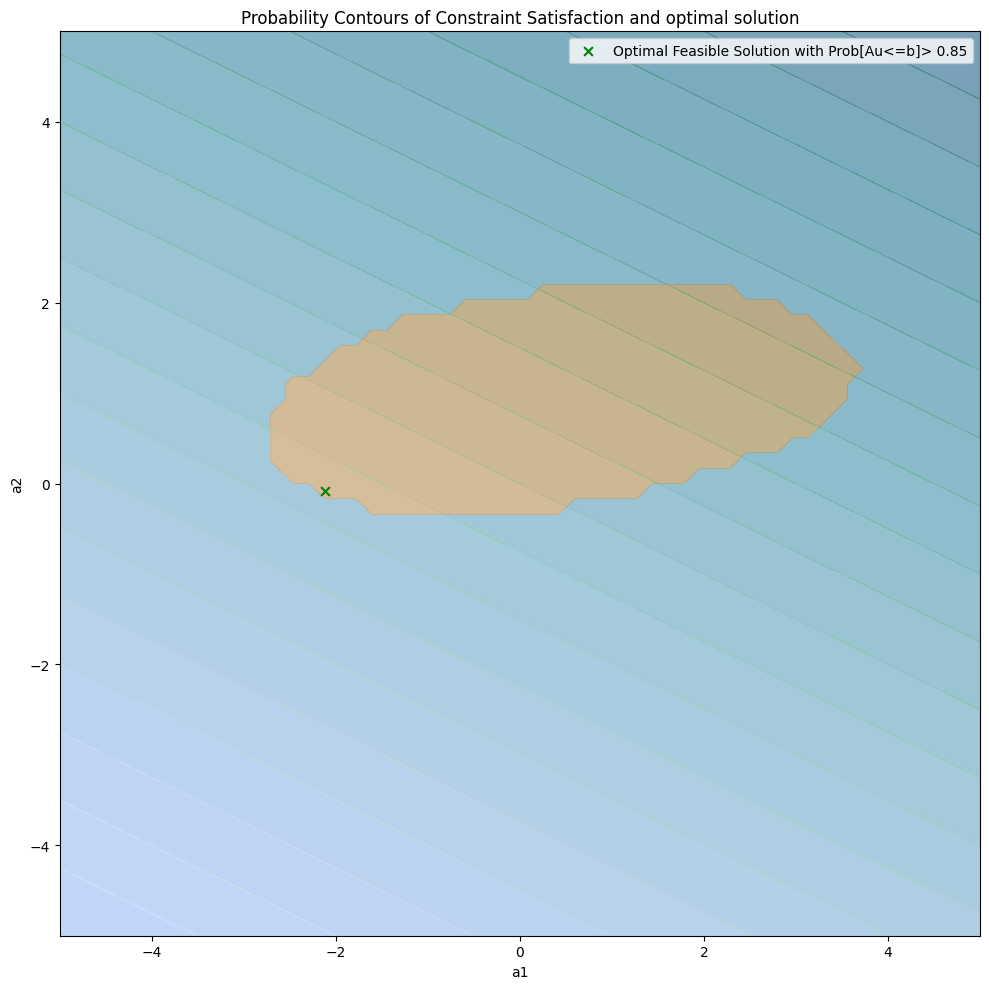

In [78]:
#@title Visualize best solution that complies with the joint CC
plt.figure(figsize=(10, 10))

one_mius_alpha = 0.85 # at least one_mius_alpha% chance of sattifying our chance constraint
feasible_mask = probability>one_mius_alpha # boolean mask on acceptable and unacceptable solutions

# Define contour levels
contour_filled = plt.contourf(A1, A2,
                              feasible_mask,
                              levels=1,
                              cmap='coolwarm',
                              alpha=0.7)  # Plot feasible region

plt.clabel(contour_lines, inline=True, fontsize=8, fmt="%.2f")  # Label contour lines
# Add colorbar
plt.contourf(A1, A2, objective_function_values, levels=20, cmap='Greens', alpha=0.3)  # Plot contour fill

feasible_objectives = objective_function_values[feasible_mask] #this was obtained for all values of a1 and a2 in a gird of points.

if feasible_objectives.size > 0:
    min_idx_in_feasible = np.argmin(feasible_objectives)

    # Step 4: Get corresponding indices in original grid
    feasible_indices = np.where(feasible_mask)
    optimal_row = feasible_indices[0][min_idx_in_feasible]
    optimal_col = feasible_indices[1][min_idx_in_feasible]

    # Step 5: Get the optimal a1 and a2 values
    optimal_a1 = A1[optimal_row, optimal_col]
    optimal_a2 = A2[optimal_row, optimal_col]

    print("Optimal a1:", optimal_a1)
    print("Optimal a2:", optimal_a2)


    plt.scatter(optimal_a1, optimal_a2, 40, color='green', marker='x', label=f'Optimal Feasible Solution with Prob[Au<=b]> {one_mius_alpha}')


else:
    print("No feasible points satisfy the probability constraint.")


# Labels and grid
plt.xlabel('a1')
plt.ylabel('a2')
plt.title('Probability Contours of Constraint Satisfaction and optimal solution')
plt.legend()
plt.tight_layout()
plt.show()

